
# Hard-Disk Monte Carlo: usage example

This notebook shows how to use `hard_disk_mc.py` as an importable module.

The code is designed for students in Statistical Mechanics 2.
It can run hard-sphere Monte Carlo in the **NVT** and **NPT** ensembles,
stores particle positions every `save_every` sweeps, and includes simple
visualization helpers.



## 1. Import the module

Place `hard_sphere_mc.py` into the same working directory as this notebook.
Then import it like any other Python module.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

import hard_disks_mc as hsmc



## 2. Run a simple NVT simulation

Here, one Monte Carlo sweep means `N` attempted particle moves.


In [2]:

result_nvt = hsmc.run_simulation(
    n_particles=36,
    t_end=200,
    temperature=1.0,
    box_length=8.0,
    sigma=1.0,
    max_displacement=0.12,
    ensemble="NVT",
    save_every=10,
    seed=42,
    initialization="cubic",
)

print("Move acceptance:", result_nvt.move_acceptance)
print("Final density:", result_nvt.metadata["final_density"])
print("Trajectory shape:", result_nvt.trajectory.shape)


Move acceptance: 0.7945833333333333
Final density: 0.5625
Trajectory shape: (21, 36, 2)


## 3. Plot the final configuration

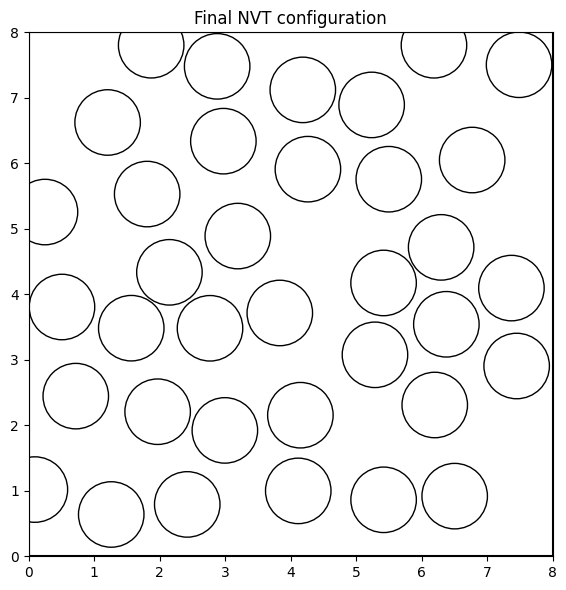

In [3]:

fig, ax = hsmc.plot_snapshot(
    result_nvt.positions,
    result_nvt.metadata["final_box_length"],
    title="Final NVT configuration",
)
plt.show()


## 4. Animate the trajectory

In [4]:

anim = hsmc.animate_trajectory(result_nvt.trajectory, result_nvt.box_lengths, interval=200)
HTML(anim.to_jshtml())



## 5. Run an NPT simulation

In NPT mode, the code attempts one isotropic volume move per sweep.
The pressure only affects acceptance probabilities in the NPT ensemble.


In [6]:

result_npt = hsmc.run_simulation(
    n_particles=36,
    t_end=200,
    temperature=1.0,
    box_length=8.0,
    pressure=5.0,
    sigma=1.0,
    max_displacement=0.10,
    max_delta_log_volume=0.01,
    ensemble="NPT",
    save_every=10,
    seed=123,
    initialization="cubic",
)

print("Move acceptance:", result_npt.move_acceptance)
print("Volume acceptance:", result_npt.volume_acceptance)
print("Final box length:", result_npt.metadata["final_box_length"])
print("Final density:", result_npt.metadata["final_density"])


Move acceptance: 0.7690277777777778
Volume acceptance: 0.47
Final box length: 7.41734503141735
Final density: 0.6543431160081454


## 6. Look at the saved positions

In [7]:

# trajectory[frame, particle, coordinate]
print("Stored trajectory array shape:", result_nvt.trajectory.shape)
print("First frame, first five particles:")
print(result_nvt.trajectory[0, :5])


Stored trajectory array shape: (21, 36, 2)
First frame, first five particles:
[[0.66666667 0.66666667]
 [0.66666667 2.        ]
 [0.66666667 3.33333333]
 [0.66666667 4.66666667]
 [0.66666667 6.        ]]



These stored positions are useful for:
- visualization,
- writing your own radial distribution function program,
- comparing equilibration at different densities.



## 7. Where to modify the code for Lennard-Jones

The hard-sphere interaction is isolated in the function
`hard_sphere_pair_energy(r, sigma, epsilon)`.

To switch to Lennard-Jones, the students can:
1. replace that function, or
2. pass another function as `pair_energy=...`.

For example, the file already contains an example function called
`lennard_jones_pair_energy`.


In [8]:

# Example only: this is how a Lennard-Jones run would look
# once you want to use the alternative pair potential.

result_lj_example = hsmc.run_simulation(
    n_particles=64,
    t_end=50,
    temperature=1.2,
    box_length=6.0,
    sigma=1.0,
    epsilon=1.0,
    max_displacement=0.10,
    ensemble="NVT",
    save_every=10,
    seed=7,
    initialization="cubic",
    pair_energy=hsmc.lennard_jones_pair_energy,
)

print("LJ example acceptance:", result_lj_example.move_acceptance)


LJ example acceptance: 0.003125



## 8. Suggested student exercises

1. Replace the hard-sphere pair potential by a Lennard-Jones potential.
2. Compare NVT and NPT simulations.
3. Measure how the acceptance rate changes with `max_displacement`.
4. Use the saved trajectory to write your own RDF code.
5. Check how the density changes over time in NPT.
